# Notebook 06 - Gated Recurrent Unit (GRU)

En este notebook implementamos una GRU, una variante simplificada de la LSTM que reduce el número de parámetros manteniendo un desempeño similar.

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
print('Listo')

Listo


## 2. Carga de Datos

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_seq.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val_seq.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_seq.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Train:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (5881, 128, 9)
Validation: (1471, 128, 9)
Test: (2947, 128, 9)


## 3. GRU vs LSTM: ¿Cuál es la diferencia?

La GRU (Gated Recurrent Unit) fue propuesta en 2014 como una simplificación de la LSTM. Las diferencias principales son:

| Aspecto | LSTM | GRU |
|---------|------|-----|
| Número de compuertas | 3 (forget, input, output) | 2 (reset, update) |
| Estados internos | 2 (celda + oculto) | 1 (solo oculto) |
| Parámetros | Más | Menos |
| Velocidad | Más lenta | Más rápida |
| Desempeño | Similar | Similar |

La GRU combina las compuertas de olvido y entrada en una sola **compuerta de actualización** (update gate), y elimina el estado de celda separado. Esto la hace más eficiente computacionalmente con resultados comparables.

## 4. Arquitectura de la GRU

In [3]:
modelo_gru = Sequential([
    # Primera capa GRU
    GRU(64, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.2),

    # Segunda capa GRU
    GRU(32, return_sequences=False),
    Dropout(0.2),

    # Capa densa
    Dense(32, activation='relu'),

    # Salida
    Dense(6, activation='softmax')
])

modelo_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,062 (97.90 KB)

 Trainable params: 25,062 (97.90 KB)

 Non-trainable params: 0 (0.00 B)

Notar que la GRU tiene menos parámetros que la LSTM equivalente. Esto la hace más rápida de entrenar, lo que puede ser ventajoso cuando los recursos computacionales son limitados.

## 5. Entrenamiento

In [4]:
modelo_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inicio = time.time()

historial = modelo_gru.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.4460 - loss: 1.2813 - val_accuracy: 0.5642 - val_loss: 1.0186
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - accuracy: 0.5843 - loss: 0.9470 - val_accuracy: 0.6900 - val_loss: 0.7224
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.6711 - loss: 0.6913 - val_accuracy: 0.7158 - val_loss: 0.5804
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.7900 - loss: 0.4972 - val_accuracy: 0.8620 - val_loss: 0.3911
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.8767 - loss: 0.3302 - val_accuracy: 0.9089 - val_loss: 0.2461
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.9148 - loss: 0.2306 - val_accuracy: 0.9320 - val_loss: 0.1803
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.9276 - loss: 0.1920 - val_accuracy: 0.9286 - val_loss: 0.1731
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9367 - loss: 0.1627 - val_accu

## 6. Curvas de aprendizaje

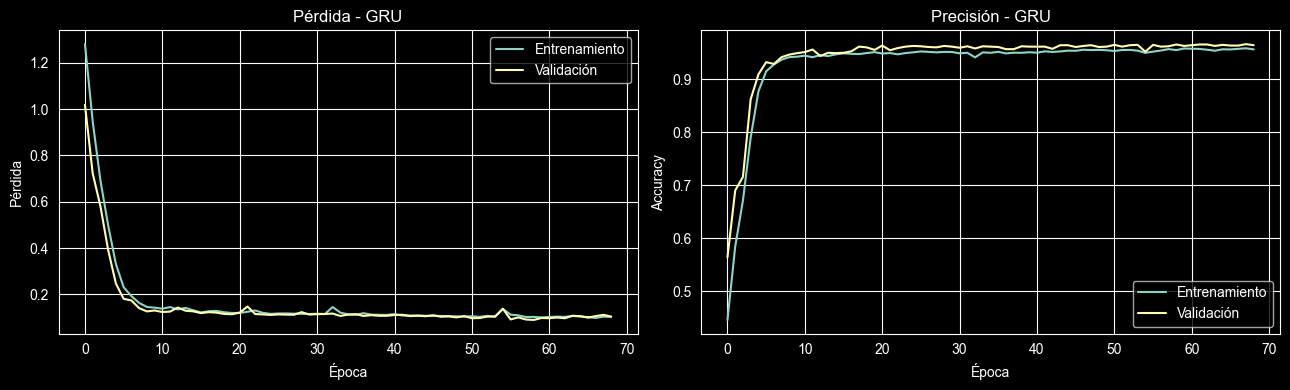

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - GRU')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - GRU')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/curvas_gru.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Evaluación

In [6]:
y_pred_prob = modelo_gru.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step
Accuracy en Test: 0.8972

                    precision    recall  f1-score   support

           WALKING       0.93      0.92      0.93       496
  WALKING_UPSTAIRS       0.94      0.94      0.94       471
WALKING_DOWNSTAIRS       0.84      0.98      0.91       420
           SITTING       0.81      0.80      0.81       491
          STANDING       0.85      0.81      0.83       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



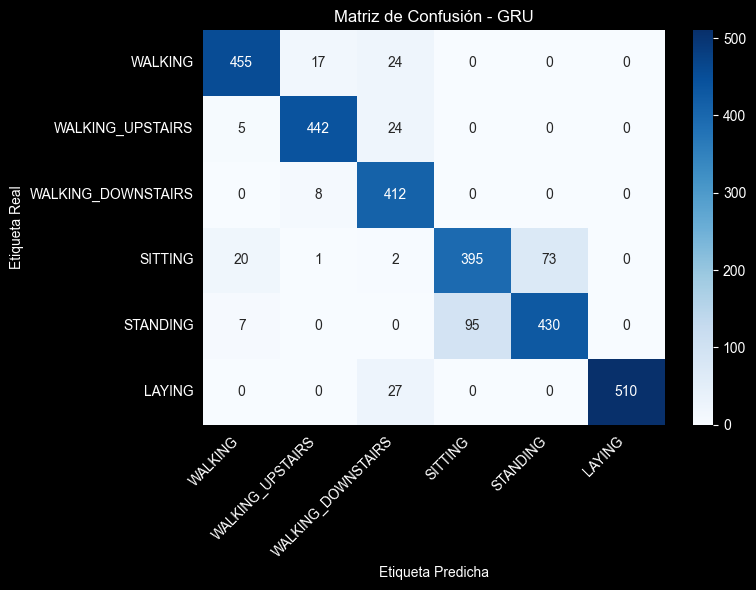

In [7]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - GRU')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_gru.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
metricas_gru = {
    'modelo': 'GRU',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

for k, v in metricas_gru.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open('../models/metricas_gru.json', 'w') as f:
    json.dump(metricas_gru, f)

modelo_gru.save('../models/modelo_gru.keras')
print('\nGuardado.')

  modelo: GRU
  accuracy: 0.8972
  precision: 0.8991
  recall: 0.8972
  f1: 0.8972
  tiempo_entrenamiento: 1213.4139

Guardado.


## 8. Comparación GRU vs LSTM

In [9]:
with open('../models/metricas_lstm.json', 'r') as f:
    metricas_lstm = json.load(f)

print('Comparación LSTM vs GRU:')
print(f'{"Métrica":<15} {"LSTM":<12} {"GRU":<12}')
print('-' * 40)
for metrica in ['accuracy', 'precision', 'recall', 'f1']:
    val_lstm = metricas_lstm[metrica]
    val_gru = metricas_gru[metrica]
    print(f'{metrica:<15} {val_lstm:<12.4f} {val_gru:<12.4f}')

print(f'\nTiempo LSTM: {metricas_lstm["tiempo_entrenamiento"]:.1f}s')
print(f'Tiempo GRU: {metricas_gru["tiempo_entrenamiento"]:.1f}s')

Comparación LSTM vs GRU:
Métrica         LSTM         GRU         
----------------------------------------
accuracy        0.9125       0.8972      
precision       0.9121       0.8991      
recall          0.9125       0.8972      
f1              0.9121       0.8972      

Tiempo LSTM: 479.7s
Tiempo GRU: 1213.4s


## Conclusiones del Modelo GRU

La GRU demuestra que es posible obtener resultados comparables a la LSTM con una arquitectura más simple:

- **Menos parámetros**: La GRU tiene aproximadamente 3/4 de los parámetros de una LSTM equivalente.
- **Entrenamiento más rápido**: Al tener menos parámetros, cada época tarda menos.
- **Desempeño similar**: En la mayoría de las tareas, incluyendo el reconocimiento de actividades, la GRU alcanza resultados muy similares a la LSTM.

En la práctica, la elección entre LSTM y GRU depende del tamaño del dataset y los recursos disponibles. Para datasets medianos como UCI HAR, la GRU suele ser la opción más eficiente.